Saving Telco_customer_churn.xlsx to Telco_customer_churn (5).xlsx


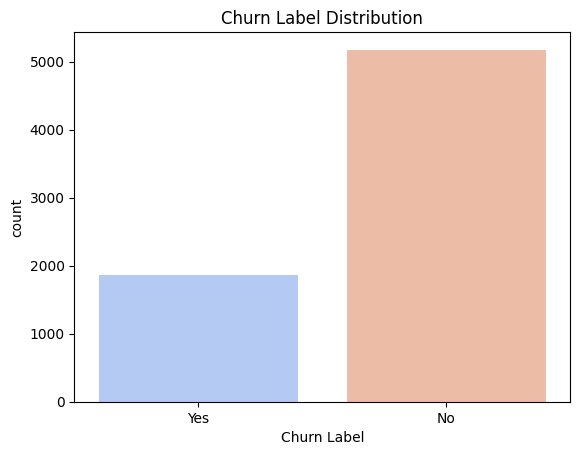

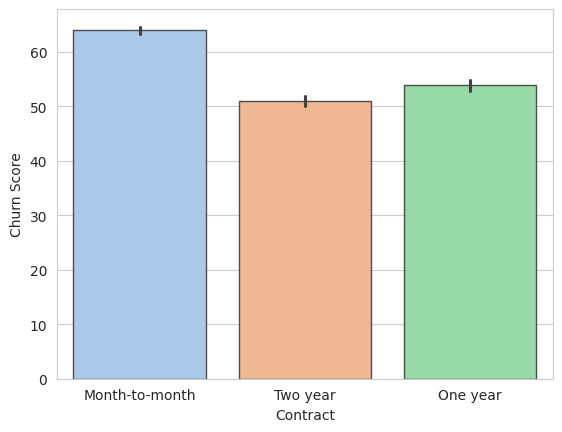

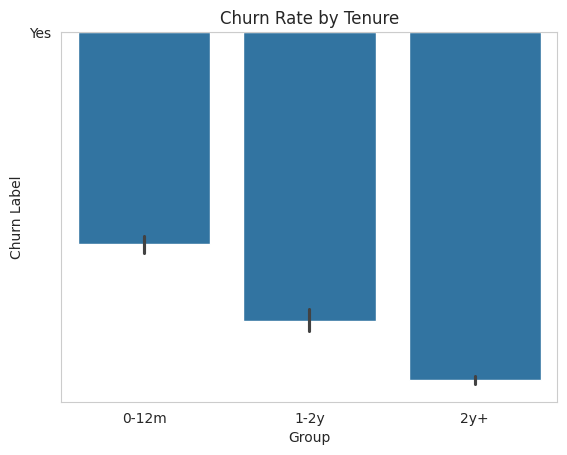

Accuracy: 0.7275

Top Feature Coefficients:
  Tenure Months: -1.4165
  Total Charges: 0.7380
  Contract_Two year: -0.6491


In [9]:
import io
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
from google.colab import files
import seaborn as sns
import matplotlib.pyplot as plt
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(io.BytesIO(uploaded[filename]))

sns.countplot(data=df, x='Churn Label', hue='Churn Label', palette='coolwarm', legend=False)
plt.title('Churn Label Distribution')
plt.show()


sns.set_style("whitegrid")
sns.barplot(data=df, x="Contract", y="Churn Score", hue="Contract", palette="pastel", edgecolor=".3", legend=False)
plt.show()


df['Group'] = pd.cut(df['Tenure Months'], bins=[0, 12, 24, 999], labels=['0-12m', '1-2y', '2y+'])
sns.barplot(data=df, x='Group', y='Churn Label', order=['0-12m', '1-2y', '2y+'])
plt.title('Churn Rate by Tenure')
plt.show()


df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)


df['Senior Citizen'] = df['Senior Citizen'].map({'Yes': 1, 'No': 0})

features = ['Tenure Months', 'Monthly Charges', 'Total Charges',
            'Senior Citizen', 'Contract', 'Payment Method',
            'Internet Service', 'Tech Support', 'Online Security',
            'Streaming Movies', 'Paperless Billing']

df_model = df[features + ['Churn Value']].dropna()


df_encoded = pd.get_dummies(df_model, columns=[
    'Contract', 'Payment Method', 'Internet Service',
    'Tech Support', 'Online Security', 'Streaming Movies', 'Paperless Billing'
], drop_first=True)

X = df_encoded.drop(columns=['Churn Value'])
y = df_encoded['Churn Value']

X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

feature_names = df_encoded.drop(columns=['Churn Value']).columns
coef_pairs = sorted(zip(feature_names, model.coef_[0]), key=lambda x: -abs(x[1]))
print("\nTop Feature Coefficients:")
for feature, coef in coef_pairs[:3]:
    print(f"  {feature}: {coef:.4f}")